# Step-by-step CEBRA

Create example data

In [37]:
# Create a .npz file
import numpy as np

X = np.random.normal(0,1,(100,3))
X_new = np.random.normal(0,1,(100,4))
np.savez("neural_data", neural = X, new_neural = X_new)

# Create a .h5 file, containing a pd.DataFrame
import pandas as pd

X_continuous = np.random.normal(0,1,(100,3))
X_discrete = np.random.randint(0,10,(100, ))
df = pd.DataFrame(np.array(X_continuous), columns=["continuous1", "continuous2", "continuous3"])
df["discrete"] = X_discrete
df.to_hdf("auxiliary_behavior_data.h5", key="auxiliary_variables")

Import CEBRA package & model

In [39]:
import cebra
from cebra import CEBRA

Load the data using cebra fx

In [40]:
# Load the .npz
neural_data = cebra.load_data(file="neural_data.npz", key="neural")

# ... and similarly load the .h5 file, providing the columns to keep
continuous_label = cebra.load_data(file="auxiliary_behavior_data.h5", key="auxiliary_variables", columns=["continuous1", "continuous2", "continuous3"])
discrete_label = cebra.load_data(file="auxiliary_behavior_data.h5", key="auxiliary_variables", columns=["discrete"]).flatten()

Model definition

In [41]:
import cebra.models
print(cebra.models.get_options('offset*', limit = 4))

['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse']


In [42]:
cebra_model = CEBRA(
    model_architecture = "offset10-model",
    batch_size = 1024,
    learning_rate = 0.001,
    max_iterations = 10,
    time_offsets = 10, # distance (in time) between positive pairs
    output_dimension = 8,
    device = "cuda_if_available",
    verbose = False
)

print(cebra_model)

CEBRA(batch_size=1024, learning_rate=0.001, max_iterations=10,
      model_architecture='offset10-model', time_offsets=10)


Model training

Single-session training

In [43]:
timesteps = 5000
neurons = 50
out_dim = 8

neural_data = np.random.normal(0,1,(timesteps, neurons))
continuous_label = np.random.normal(0,1,(timesteps, 3))
discrete_label = np.random.randint(0,10,(timesteps,))

single_cebra_model = cebra.CEBRA(batch_size=512,
                                 output_dimension=out_dim,
                                 max_iterations=10,
                                 max_adapt_iterations=10)

fit the model in different modes

In [44]:
# CEBRA-Time (time-contrastive training) with chosen time_offsets
#single_cebra_model.fit(neural_data)

# CEBRA-Behavior (supervised constrastive learning) using discrete labels
single_cebra_model.fit(neural_data, discrete_label)

# CEBRA-Behavior (supervised constrastive learning) using continuous labels
#single_cebra_model.fit(neural_data, continuous_label)

# CEBRA-Behavior (supervised constrastive learning) using a mix of discrete and continuous labels
#single_cebra_model.fit(neural_data, continuous_label, discrete_label)

,model_architecture,'offset1-model'
,device,'cuda_if_available'
,criterion,'infonce'
,distance,'cosine'
,conditional,None
,temperature,1.0
,temperature_mode,'constant'
,min_temperature,0.1
,time_offsets,1
,delta,None
,max_iterations,10


Multi-session training

In [45]:
timesteps1 = 5000
timesteps2 = 3000
neurons1 = 50
neurons2 = 30
out_dim = 8

neural_session1 = np.random.normal(0,1,(timesteps1, neurons1))
neural_session2 = np.random.normal(0,1,(timesteps2, neurons2))
continuous_label1 = np.random.uniform(0,1,(timesteps1, 3)) # also can be changed to discrete 
continuous_label2 = np.random.uniform(0,1,(timesteps2, 3))

multi_cebra_model = cebra.CEBRA(batch_size=512,
                                output_dimension=out_dim,
                                max_iterations=10,
                                max_adapt_iterations=10)

In [46]:
multi_cebra_model.fit([neural_session1, neural_session2], [continuous_label1, continuous_label2])

,model_architecture,'offset1-model'
,device,'cuda_if_available'
,criterion,'infonce'
,distance,'cosine'
,conditional,None
,temperature,1.0
,temperature_mode,'constant'
,min_temperature,0.1
,time_offsets,1
,delta,None
,max_iterations,10


Saving/Loading a model

In [47]:
import tempfile
from pathlib import Path

# create temporary file to save the model
tmp_file = Path(tempfile.gettempdir(), 'cebra.pt')

cebra_model = cebra.CEBRA(max_iterations=10)
cebra_model.fit(neural_data)

# Save the model (trained/untrained)
cebra_model.save(tmp_file)

# in a new session: load and use the model
loaded_cebra_model = cebra.CEBRA.load(tmp_file)
embedding = loaded_cebra_model.transform(neural_data)

Grid search

In [48]:
# define the parameters
params_grid = dict(
    output_dimension = [3, 16],
    learning_rate = [0.001],
    time_offsets = 5,
    max_iterations = 5,
    temperature_mode='constant',
    temperature = 0.1,
    verbose = False)

# define the datasets to iterate over
datasets = {"dataset1": neural_session1,                      # time contrastive learning
            "dataset2": (neural_session1, continuous_label1), # behavioral contrastive learning
            "dataset3": (neural_session2, continuous_label2)} # a different set of data

# create and fit the grid search to the data
grid_search = cebra.grid_search.GridSearch()
grid_search.fit_models(datasets=datasets, params=params_grid, models_dir="saved_models")

In [49]:
# get the results of the search
df_results = grid_search.get_df_results(models_dir="saved_models")

# get the best model for a given dataset
best_model, best_model_name = grid_search.get_best_model(dataset_name="dataset2", models_dir="saved_models")

print(best_model_name)
print(best_model)

output_dimension_3_dataset2
CEBRA(learning_rate=0.001, max_iterations=5, output_dimension=3,
      temperature=0.1, time_offsets=5)


Compute the embedding

In [50]:
embedding = single_cebra_model.transform(neural_data)
assert(embedding.shape == (timesteps, out_dim))
print(embedding.shape) # (size time, output_dimension)

multi_embedding = multi_cebra_model.transform(neural_session1, session_id=0)
assert(multi_embedding.shape == (timesteps1, out_dim))
print(multi_embedding.shape) # (size time, output_dimension)

(5000, 8)
(5000, 8)


Visualizations

<Axes3D: title={'center': 'Embedding'}>

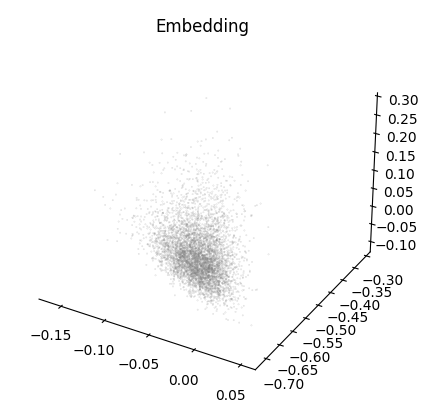

In [51]:
# plot the embedding
cebra.plot_embedding(embedding)

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

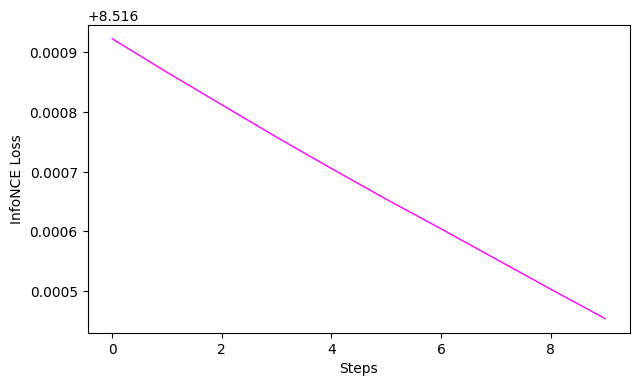

In [52]:
# plot the training loss
cebra.plot_loss(cebra_model)

<Axes: xlabel='Steps', ylabel='Temperature'>

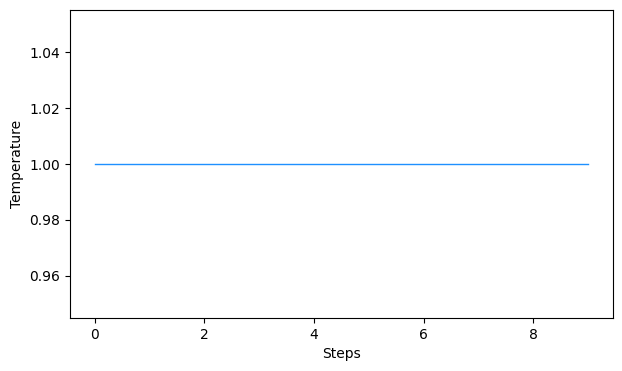

In [53]:
# plot the temperature
cebra.plot_temperature(cebra_model)

Compare models

In [54]:
cebra_posdir_model = CEBRA(model_architecture='offset10-model',
                batch_size=512,
                output_dimension=32,
                max_iterations=5,
                time_offsets=10)
cebra_posdir_model.fit(neural_data, continuous_label, discrete_label)

cebra_pos_model = CEBRA(model_architecture='offset10-model',
            batch_size=512,
            output_dimension=32,
            max_iterations=5,
            time_offsets=10)
cebra_pos_model.fit(neural_data, continuous_label)

cebra_dir_model = CEBRA(model_architecture='offset10-model',
            batch_size=512,
            output_dimension=32,
            max_iterations=5,
            time_offsets=10)
cebra_dir_model.fit(neural_data, discrete_label)

,model_architecture,'offset10-model'
,device,'cuda_if_available'
,criterion,'infonce'
,distance,'cosine'
,conditional,None
,temperature,1.0
,temperature_mode,'constant'
,min_temperature,0.1
,time_offsets,10
,delta,None
,max_iterations,5


<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

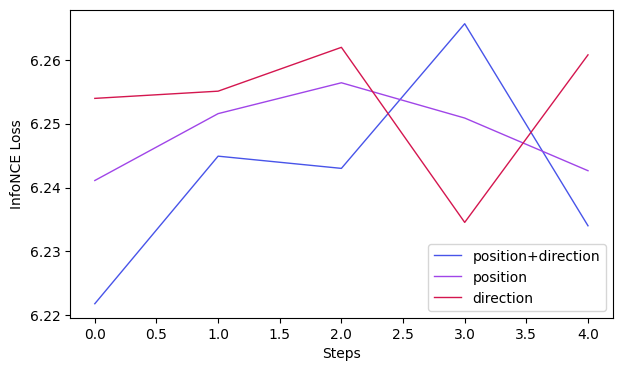

In [32]:
# Labels to be used for the legend of the plot (optional)
labels = ["position+direction", "position", "direction"]

cebra.compare_models([cebra_posdir_model, cebra_pos_model, cebra_dir_model], labels)

Decoding

In [56]:
from sklearn.model_selection import train_test_split

# 1. Train a CEBRA-Time model on the whole dataset
cebra_model = cebra.CEBRA(max_iterations=10)
cebra_model.fit(neural_data)
embedding = cebra_model.transform(neural_data)

# 2. Split the embedding and label to decode into train/validation sets
(
     train_embedding,
     valid_embedding,
     train_discrete_label,
     valid_discrete_label,
) = train_test_split(embedding,
                     discrete_label,
                     test_size=0.3)

# 3. Train the decoder on the training set
decoder = cebra.KNNDecoder()
decoder.fit(train_embedding, train_discrete_label)

# 4. Get the score on the validation set
score = decoder.score(valid_embedding, valid_discrete_label)

# 5. Get the discrete labels predictions
prediction = decoder.predict(valid_embedding)

print(score)
print(prediction)

-1.1373533518698782
[1 3 6 ... 4 0 3]
